# Example of the AiTLAS toolbox for semantic segmentation using TerraMind

## Define the FAIREOSchema for dataset import

In [ ]:
from marshmallow import fields

from aitlas.base.schemas import BaseDatasetSchema


class FAIREOSchema(BaseDatasetSchema):
    """
    Schema for FAIREO datasets.
    """

    csv_file = fields.String(
        load_default=None,
        metadata={"description": "CSV file on disk", "example": "./data/train.csv"},
    )
    data_dir = fields.String(
        load_default="/",
        metadata={"description": "Dataset path on disk", "example": "./data/CESBIO/"},
    )
    selection = fields.String(
        load_default="rgb",
        metadata={"description": "Read RGB channels or 13 channels", "example": "all/rgb"},
    )
    mode = fields.String(
        load_default=None, metadata={"description": "train/val or test task", "example": "train"}
    )

/home/dragik/tadej/aitlas/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/dragik/tadej/aitlas/aitlas/models/AnySat/utils/irpe.py:18: UserWarning: 
  warnings.warn(
/home/dragik/tadej/aitlas/.venv/lib/python3.12/site-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


## Define the DLRSD dataset
DLRSD (Dense Labeling Remote Sensing Dataset) is a dense labeling dataset that can 
be used for multi-label tasks such as remote sensing image retrieval (RSIR) and 
classification, and other pixel-based tasks like semantic segmentation. It has 21 
broad categories with 100 images per class, and 17 segmentation classes.

In [2]:
import numpy as np
import os
import pandas as pd
import csv

from aitlas.datasets.semantic_segmentation import SemanticSegmentationDataset
from aitlas.utils import image_loader


class DLRSDDataset(SemanticSegmentationDataset):
    url = "https://sites.google.com/view/zhouwx/dataset#h.p_hQS2jYeaFpV0"

    labels = [
        "no data",
        "airplane",
        "bare soil",
        "buildings",
        "cars",
        "chaparral",
        "court",
        "dock",
        "field",
        "grass",
        "mobile home",
        "pavement",
        "sand",
        "sea",
        "ship",
        "tanks",
        "trees",
        "water",
    ]
    color_mapping = [
        [0, 0, 0],
        [165, 202, 239],
        [128, 130, 0],
        [1, 0, 126],
        [254, 2, 0],
        [0, 128, 0],
        [126, 0, 1],
        [251, 229, 230],
        [159, 158, 163],
        [2, 128, 129],
        [87, 85, 249],
        [249, 253, 4],
        [253, 190, 8],
        [0, 2, 249],
        [251, 0, 190],
        [126, 0, 133],
        [1, 252, 1],
        [4, 251, 253],
    ]
    name = "DLRSD"
    schema = FAIREOSchema

    def __init__(self, config):
        # now call the constructor to validate the schema and split the data
        super().__init__(config)
        self.data_dir = self.config.data_dir
        self.selection = self.config.selection
        self.csv_file = self.config.csv_file

    def __getitem__(self, index):
        image = image_loader(self.images[index])
        mask = image_loader(self.masks[index])
        masks = [(mask == v) for v, label in enumerate(self.labels)]
        mask = np.stack(masks, axis=-1).astype("float32")

        return self.apply_transformations(image, mask)

    def load_dataset(self, data_dir, csv_file):
        if not self.labels:
            raise ValueError("You need to provide the list of labels for the dataset")

        ids = os.listdir(os.path.join(data_dir, "Images"))

        split_list = []
        ids_final = []
        if csv_file:
            with open(csv_file, mode="r") as file:
                csvFile = csv.reader(file)
                for lines in csvFile:
                    split_list.append(lines[0])
            for i in ids:
                i_csv = "Images/" + i
                if i_csv in split_list:
                    ids_final.append(i)
            ids = ids_final

        self.images = [os.path.join(data_dir, "Images", image_id) for image_id in ids]
        self.masks = [
            os.path.join(data_dir, "Labels", image_id[: image_id.rfind(".tif")] + ".png")
            for image_id in ids
        ]

    def data_distribution_table(self):
        label_dist = {key: 0 for key in self.labels}
        for image, mask in self.dataloader():
            for index, label in enumerate(self.labels):
                label_dist[self.labels[index]] += mask[:, :, :, index].sum()
        label_count = pd.DataFrame.from_dict(label_dist, orient="index")
        label_count.columns = ["Number of pixels"]
        label_count = label_count.astype(float)
        return label_count

/home/dragik/tadej/aitlas/.venv/lib/python3.12/site-packages/fs/__init__.py:4: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  __import__("pkg_resources").declare_namespace(__name__)  # type: ignore


## Visualize images and masks

Total number of patches: 2100


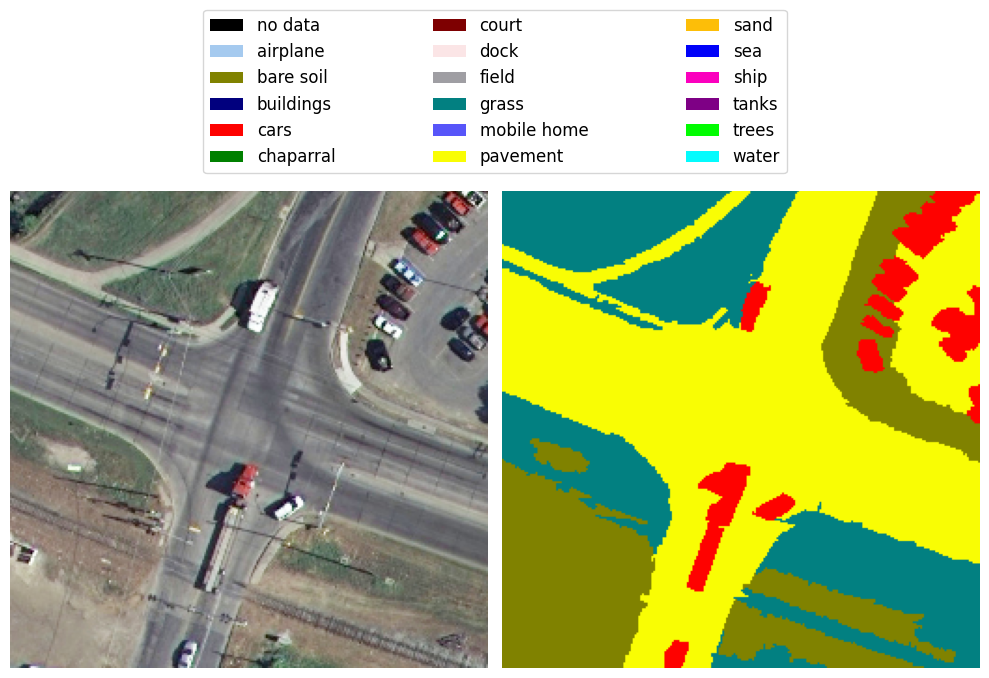

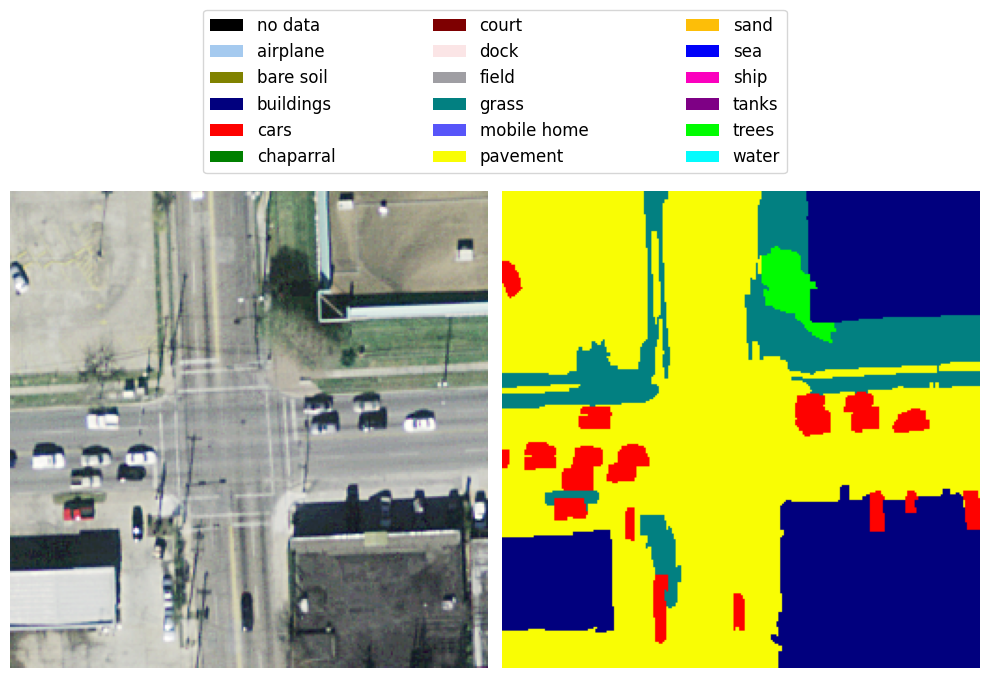

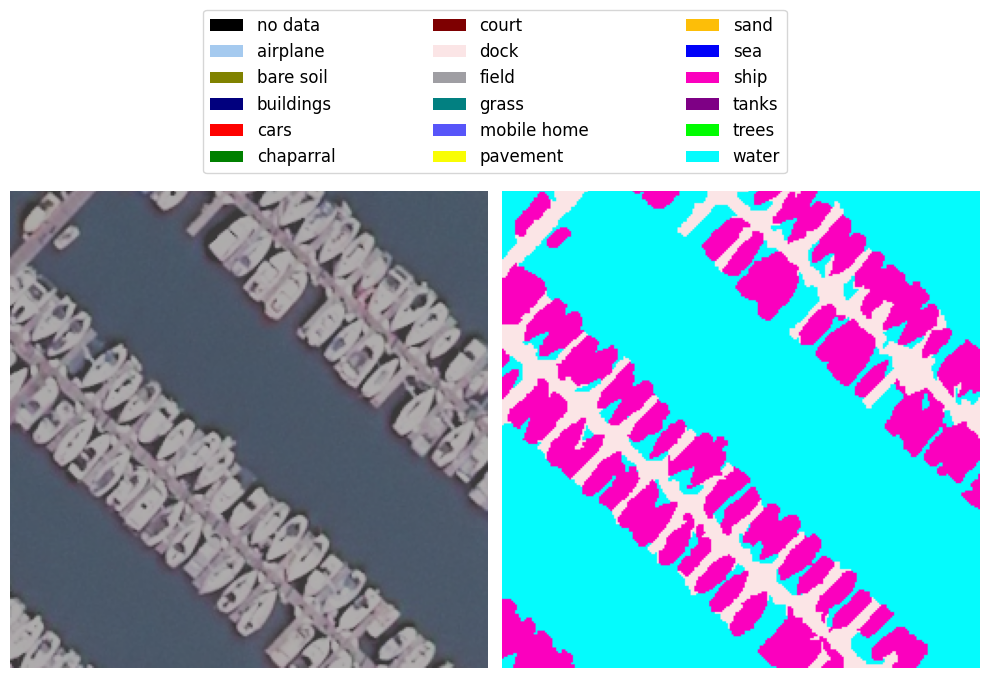

In [3]:
dataset_config = {
    "data_dir": "/home/dragik/data/FAIR_EO/DLRSD"
}
dataset = DLRSDDataset(dataset_config)

print(f"Total number of patches: {len(dataset)}")
dataset.show_image(1);
dataset.show_image(3);
dataset.show_image(8);

## Define train and test datasets

In [5]:
# Train dataset
train_dataset_config = {
    "batch_size": 8,
    "shuffle": True,
    "num_workers": 4,
    "data_dir": "/home/dragik/data/FAIR_EO/DLRSD",
    "csv_file": "/home/dragik/data/FAIR_EO/DLRSD/dlrsd_train.csv",
    "transforms": ["aitlas.transforms.MinMaxNormTranspose","aitlas.transforms.ResizeToTensor"], 
    "target_transforms": ["aitlas.transforms.Transpose","aitlas.transforms.ResizePerChannelToTensor"] 
}
train_dataset = DLRSDDataset(train_dataset_config)
print(f"Number of training samples: {len(train_dataset)}")

# Validation dataset
val_dataset_config = {
    "batch_size": 8,
    "shuffle": True,
    "num_workers": 4,
    "data_dir": "/home/dragik/data/FAIR_EO/DLRSD",
    "csv_file": "/home/dragik/data/FAIR_EO/DLRSD/dlrsd_val.csv",
    "transforms": ["aitlas.transforms.MinMaxNormTranspose","aitlas.transforms.ResizeToTensor"], 
    "target_transforms": ["aitlas.transforms.Transpose","aitlas.transforms.ResizePerChannelToTensor"] 
}
val_dataset = DLRSDDataset(val_dataset_config)
print(f"Number of validation samples: {len(val_dataset)}")

# Test dataset
test_dataset_config = {
    "batch_size": 4,
    "shuffle": False,
    "num_workers": 4,
    "data_dir": "/home/dragik/data/FAIR_EO/DLRSD",
    "csv_file": "/home/dragik/data/FAIR_EO/DLRSD/dlrsd_test.csv",
    "transforms": ["aitlas.transforms.MinMaxNormTranspose","aitlas.transforms.ResizeToTensor"], 
    "target_transforms": ["aitlas.transforms.Transpose","aitlas.transforms.ResizePerChannelToTensor"] 
}

test_dataset = DLRSDDataset(test_dataset_config)
print(f"Number of test samples: {len(test_dataset)}")

Number of training samples: 1260
Number of validation samples: 420
Number of test samples: 420


## Prepare the model

In [6]:
import torch
from aitlas.base import CompositeModel


# Define the config file
config_data = {
    # Task definition
    "task_type": "segmentation",
    "num_classes": 18,
    # Training parameters
    "learning_rate": 0.0001,
    "metrics": ["accuracy", "precision", "recall", "f1_score", "iou"],
    # Data-model adapter configuration
    "adapter_name": "TerraMindAdapter",
    # Backbone configuration
    "local_model_path": "tests/checkpoints/TerraMind_v1_base.pt",
    "backbone_name": "terramind_v1_base",
    "pretrained": True,
    "modalities": ["RGB"],
    # Neck configuration
    "necks": [
        {"name": "SelectIndices", "indices": [2, 5, 8, 11]}, 
        {"name": "ReshapeTokensToImage", "remove_cls_token": False}, 
        {"name": "LearnedInterpolateToPyramidal"}
    ],
    # Decoder configuration
    "decoder_name": "UPerNetDecoder",
    "decoder_params": {"channels": 256, "pool_scales": [1, 2, 3, 6]},
    # Head configuration
    "head_name": "SegmentationHead",
    "head_params": {"dropout": 0.1},
}

print(f"Instantiating CompositeModel with backbone: {config_data['backbone_name']}")

# Instantiate the CompositeModel
model = CompositeModel(config_data)
model.prepare()
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model.to(device)

# Print the architecture
print("\nComposite model architecture created:")
print(f"  Adapter:  {type(model.input_adapter).__name__}")
print(f"  Backbone: {type(model.model.backbone).__name__}")
print(f"  Neck(s):  {', '.join([type(model.model.necks[i]).__name__ for i in range(len(model.model.necks))])}")
print(f"  Decoder:  {type(model.model.decoder).__name__}")
print(f"  Head:     {type(model.model.head).__name__}")
print(f"\nModel successfully loaded on device: {device}")

Instantiating CompositeModel with backbone: terramind_v1_base
Loading weights from the provided local path: tests/checkpoints/TerraMind_v1_base.pt
Successfully loaded checkpoint: TerraMind_v1_base.pt

Composite model architecture created:
  Adapter:  TerraMindAdapter
  Backbone: TerraMind
  Neck(s):  SelectIndices, ReshapeTokensToImage, LearnedInterpolateToPyramidal
  Decoder:  UPerNetDecoder
  Head:     SegmentationHead

Model successfully loaded on device: cuda:0


## Train and evaluate the model

In [7]:
epochs = 10
model_directory = "/home/dragik/data/FAIR_EO/DLRSD"

model.train_and_evaluate_model(
    train_dataset=train_dataset,
    val_dataset=val_dataset,
    test_dataset=test_dataset,
    epochs=epochs,
    model_directory=model_directory,
    run_id='1'
);

2026-05-06 10:37:32,536 INFO Starting training.
training: 100%|██████████| 158/158 [00:21<00:00,  7.18it/s]
2026-05-06 10:37:54,536 INFO epoch: 1, time: 22, loss:  0.71990
testing on train set: 100%|██████████| 158/158 [00:09<00:00, 16.11it/s]
2026-05-06 10:38:07,456 INFO Accuracy:0.9463741833991264, Accuracy per Class:[0.99999941 0.99683751 0.85842984 0.89347363 0.97452206 0.9685407
 0.98555257 0.99123542 0.98772314 0.8267791  0.98260815 0.8263695
 0.96848378 0.96984921 0.98411284 0.99007708 0.86990082 0.96024054], Precision Micro:0.5173676505921379, Precision Macro:0.45368834741724157, Precision Weighted:0.5298196710828702, Precision per Class:[0.         0.21575153 0.30150078 0.44653979 0.89849389 0.3901228
 0.07867331 0.2578437  0.81181826 0.4509133  0.65895555 0.67679631
 0.54816496 0.51616246 0.54889059 0.2891143  0.49749717 0.57915158], Recall Micro:0.5173676505921379, Recall Macro:0.31684942420697826, Recall Weighted:0.517367650592138, Recall per Class:[0.00000000e+00 1.4954693

## Make predictions

2026-05-06 10:43:37,974 INFO Loading checkpoint /home/dragik/data/FAIR_EO/DLRSD/checkpoint.pth.tar
2026-05-06 10:43:38,429 INFO Loaded checkpoint /home/dragik/data/FAIR_EO/DLRSD/checkpoint.pth.tar at epoch 11


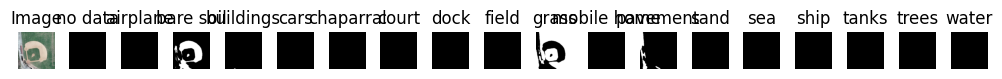

: 

In [ ]:
from aitlas.transforms import MinMaxNormTranspose

# Load the model
model_path = "/home/dragik/data/FAIR_EO/DLRSD/checkpoint.pth.tar"
device = torch.device("cuda:0")
model.device = device
model.load_model(model_path)

# Define the labels and transformation
labels = DLRSDDataset.labels
transform = MinMaxNormTranspose()

# Predict on a test image
image = test_dataset[1][0]
fig = model.predict_masks(image, labels)